# EX01: Regular Languages and Regular Expressions

## Grammar Engineering

## MEI/2026-27

#### Nuno Macedo
Universidade do Minho

The following exercises review:
- Regular Languages (RLs), Deterministic Finite Automata (DFAs), Non-deterministic Finite Automata (NFAs), Non-deterministic Finite Automata with $\varepsilon$ transitions ($\varepsilon$NFA), and Regular Expressions (REs); these can be solved with pen-and-paper or animated using the [`automata-lib`](https://pypi.org/project/automata-lib/) Python module.
- Regular expressions in practice using Python's [`re`](https://docs.python.org/3/library/re.html) module

In [ ]:
# libraries to allow the visualization and manipulation of automata
!apt-get update -qq
!apt-get install -y -qq graphviz graphviz-dev
!pip install -q pygraphviz coloraide
!pip install -q automata-lib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import doctest

## Exercise 1 - Formal language representations

Consider a simplified language of **version strings**.

A version consists of:
- exactly three numeric components separated by `.`
- an optional pre-release identifier introduced by `-`
- a pre-release identifier starts with a lowercase letter and may contain lowercase letters and digits

For example

```text
1.0.0
2.14.3
10.20.300
1.0.0-alpha
1.2.3-beta12
2.0.1-rc
```

are valid ✅ version strings, while
```text
1
1.2
1.2.3.4
1..2.3
1.2.a
1.2.3-
1.2.3-123
1.2.3-Alpha
```

are not ❌.

### Exercise 1.1 - Regular expressions

Consider the following RE:

In [ ]:
regex = r"[0-9]+\.[0-9]+\.[0-9]+(-[a-z][a-z0-9]*)?"

#### Exercise 1.1.1

Does the `regex` RE recognize the language specified above? If so, explain how it corresponds to the structure of a version
string.

#### Exercise 1.1.2

Use Python's [`re`](https://docs.python.org/3/library/re.html) module to investigate this specification, namely validating the provided example strings.

In [ ]:
import re

In [ ]:
def versionStringRE(version):
  """
  >>> versionStringRE("1.0.0")
  True
  >>> versionStringRE("2.14.3")
  True
  >>> versionStringRE("10.20.300")
  True
  >>> versionStringRE("1.0.0-alpha")
  True
  >>> versionStringRE("1.2.3-beta12")
  True
  >>> versionStringRE("2.0.1-rc")
  True
  >>> versionStringRE("1")
  False
  >>> versionStringRE("1.2")
  False
  >>> versionStringRE("1.2.3.4")
  False
  >>> versionStringRE("1..2.3")
  False
  >>> versionStringRE("1.2.a")
  False
  >>> versionStringRE("1.2.3-")
  False
  >>> versionStringRE("1.2.3-123")
  False
  >>> versionStringRE("1.2.3-Alpha")
  False
  """
  return None


In [ ]:
doctest.run_docstring_examples(versionStringRE, globals())

#### Exercise 1.1.3

Write a Python function using the module `re` to convert a provided version string into a dictionary identifying the different fields.

In [ ]:
def processVersionStringRE(version):
  """
  >>> processVersionStringRE("1.0.0")
  {'fst': '1', 'snd': '0', 'trd': '0', 'pre': None}
  >>> processVersionStringRE("2.14.3")
  {'fst': '2', 'snd': '14', 'trd': '3', 'pre': None}
  >>> processVersionStringRE("10.20.300")
  {'fst': '10', 'snd': '20', 'trd': '300', 'pre': None}
  >>> processVersionStringRE("1.0.0-alpha")
  {'fst': '1', 'snd': '0', 'trd': '0', 'pre': 'alpha'}
  >>> processVersionStringRE("1.2.3-beta12")
  {'fst': '1', 'snd': '2', 'trd': '3', 'pre': 'beta12'}
  >>> processVersionStringRE("2.0.1-rc")
  {'fst': '2', 'snd': '0', 'trd': '1', 'pre': 'rc'}
  """
  return None


In [ ]:
doctest.run_docstring_examples(processVersionStringRE, globals())

### Exercise 1.2 - Finite Automata

Consider the following DFA:


In [ ]:
from automata.fa.dfa import DFA
from automata.fa.nfa import NFA

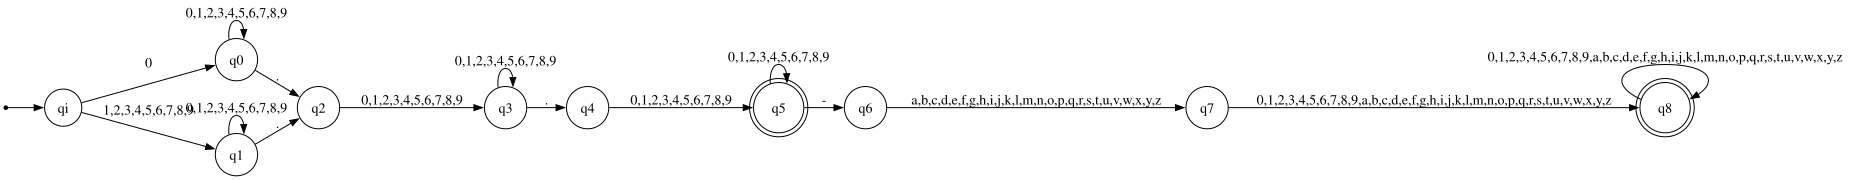

In [ ]:
digits = set("0123456789")
letters = set("abcdefghijklmnopqrstuvwxyz")
alphanumeric = digits | letters
alphabet = digits | letters | {".", "-"}

transitions = {
    "qi": {"0": "q0"} | {d: "q1" for d in "123456789"},
    "q0": {d: "q0" for d in digits} | {".": "q2"},
    "q1": {d: "q1" for d in digits} | {".": "q2"},
    "q2": {d: "q3" for d in digits},
    "q3": {d: "q3" for d in digits} | {".": "q4"},
    "q4": {d: "q5" for d in digits},
    "q5": {d: "q5" for d in digits} | {"-": "q6"},
    "q6": {c: "q7" for c in letters},
    "q7": {c: "q8" for c in alphanumeric},
    "q8": {c: "q8" for c in alphanumeric},
}

states = {"qi", "q0", "q1", "q2", "q3", "q4", "q5", "q6", "q7", "q8"}

version_dfa = DFA(
    states=states,
    input_symbols=alphabet,
    transitions=transitions,
    initial_state="qi",
    final_states={"q5", "q8"},
    allow_partial=True
)

version_dfa

#### Exercise 1.2.1

Does this DFA recognize the language specified above? For each state, explain what the state represents about the input processed
so far.

#### Exercise 1.2.2

Use Python's [`automata-lib`](https://pypi.org/project/automata-lib/)  module to investigate this specification, namely validating the provided example strings.

In [ ]:
def versionStringFA(version):
  """
  >>> versionStringFA("1.0.0")
  True
  >>> versionStringFA("2.14.3")
  True
  >>> versionStringFA("10.20.300")
  True
  >>> versionStringFA("1.0.0-alpha")
  True
  >>> versionStringFA("1.2.3-beta12")
  True
  >>> versionStringFA("2.0.1-rc")
  True
  >>> versionStringFA("1")
  False
  >>> versionStringFA("1.2")
  False
  >>> versionStringFA("1.2.3.4")
  False
  >>> versionStringFA("1..2.3")
  False
  >>> versionStringFA("1.2.a")
  False
  >>> versionStringFA("1.2.3-")
  False
  >>> versionStringFA("1.2.3-123")
  False
  >>> versionStringFA("1.2.3-Alpha")
  False
  """
  return None


In [ ]:
doctest.run_docstring_examples(versionStringFA, globals())

### Exercise 1.3 - Equivalence of representations

The two representations (RE and DFA) produce the same result for all the provided
examples.

#### Exercise 1.3.1

Are the RE and the DFA equivalent?

If not, provide a string that is accepted by one representation and rejected by the other.

#### Exercise 1.3.2

Testing individual strings cannot establish that two representations
recognize exactly the same language.

How can we formally determine whether two representations recognize the same
language?

#### Exercise 1.3.3

Use `automata-lib` to apply the strategy described in the previous exercise
and compare the two representations.

#### Exercise 1.3.4

Adapt the RE so that it describes the same language as the
provided DFA.

## Exercise 2 - A security bot controller

Consider the following NFA, which models a security bot operating in a restricted facility.

The bot can react to the following events:

```text
boot, patrol, detect, identify, reset, recharge, shutdown
```

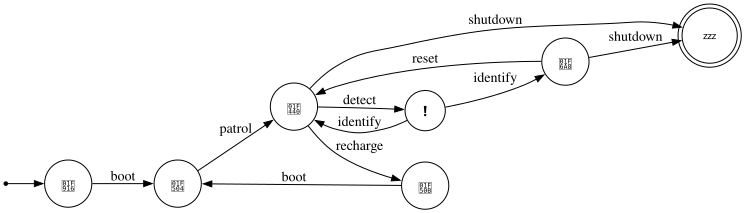

In [ ]:
states = {
    "🤖",   # powered off
    "🔄",   # booting
    "👀",   # patrolling
    "❗",   # detection
    "🚨",   # alarm
    "🔋",   # recharging
    "💤"    # shutdown
}

input_symbols = {
    "boot",
    "patrol",
    "detect",
    "identify",
    "reset",
    "recharge",
    "shutdown"
}

transitions = {
    "🤖": { "boot": {"🔄"} },
    "🔄": { "patrol": {"👀"} },
    "👀": { "detect": {"❗"}, "recharge": {"🔋"}, "shutdown": {"💤"} },
    "❗": { "identify": {"👀", "🚨"}, },
    "🚨": { "reset": {"👀"}, "shutdown": {"💤"} },
    "🔋": { "boot": {"🔄"}, },
    "💤": {}
}

security_bot = NFA(
    states=states,
    input_symbols=input_symbols,
    transitions=transitions,
    initial_state="🤖",
    final_states={"💤"}
)

security_bot

### Exercise 2.1 - Understanding the controller


#### Exercise 2.1.1

What do the states of the NFA represent?

Describe the meaning of each state based on the transitions and the
behaviour of the controller.

What does the accepting state represent in the context of the controller?

#### Exercise 2.1.2

Present a sequence of events that is accepted by the NFA, and another that
is rejected.

Use Python's [`automata-lib`](https://pypi.org/project/automata-lib/)  to validate those sequences.

#### Exercise 2.1.3

Identify where non-determinism occurs in the NFA. Propose an DFA equivalent to the provided NFA.

### Exercise 2.2 - Extending the NFA

Consider now that the bot has a low-battery mode, which it enters when its
battery is depleted during patrol.

Consider a new event `deplete` and extend the NFA to support this behavior.

## Exercise 3 - Matching delimiters

Suppose a file-recovery application has recovered fragments of text from a damaged file. Some fragments appear to contain useful information enclosed by delimiters.

Use Python's [`re`](https://docs.python.org/3/library/re.html) module to recover the enclosed information.

In [ ]:
fragment = """
x9a8d7f@@ha9a8d9ads@@k3jd82k
91ks7d@#@dkjsad99adkad@#@d8a7s6d
q2w9e@@9012@@4k8s1@@3123@@z7x6c
m3n8b@#@alaisud9@#@p4q7r@#@913kadsd@#@t6y2u
"""

### 3.1 - Fixed delimiters

Assume that the delimiters are exactly `@@`.

In [ ]:
def delim1(text):
  """
  >>> delim1(fragment)
  ['ha9a8d9ads', '9012', '3123']
  """
  return None

doctest.run_docstring_examples(delim1, globals())

### 3.2 - Repeated delimiters

Assume that delimiters are any sequence of symbols `@`, `#`, and `$`.

In [ ]:
def delim2(text):
  """
  >>> delim2(fragment)
  ['ha9a8d9ads', 'dkjsad99adkad', '9012', '3123', 'alaisud9', '913kadsd']
  """
  return None

doctest.run_docstring_examples(delim2, globals())

### 3.3 - Sequenced fixed delimiters

Assume that the delimiters are exactly `@@`, but that the same delimiter can close a segment and open another one.

In [ ]:
def delim3(text):
  """
  >>> delim3(fragment)
  ['ha9a8d9ads', '9012', '4k8s1', '3123']
  """
  return None

doctest.run_docstring_examples(delim3, globals())

### 3.4 — Sequenced repeated delimiters

Assume that delimiters are any sequence of symbols `@`, `#`, and `$`., but that the same delimiter can close a segment and open another one.

In [ ]:
def delim4(text):
  """
  >>> delim4(fragment)
  ['ha9a8d9ads', 'dkjsad99adkad', '#', '9012', '4k8s1', '3123', 'alaisud9', 'p4q7r', '913kadsd', '#']
  """
  return None

doctest.run_docstring_examples(delim4, globals())

-- Nuno Macedo, 2026-09-24